# Titanic - Machine Learning from Disaster

A complete, end-to-end workflow for the Kaggle Titanic competition:

1. Load data
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Preprocessing pipeline
5. Model training & comparison (with cross-validation)
6. Hyperparameter tuning of the best model
7. Final fit & prediction
8. Submission file generation

> If you're running this on Kaggle, the data will already be available at `/kaggle/input/titanic/`. If you're running it locally, place `train.csv` and `test.csv` in the same folder as this notebook (or update `DATA_DIR` below).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load Data

In [5]:
# Works both on Kaggle and locally
if os.path.exists('/kaggle/input/titanic/train.csv'):
    DATA_DIR = '/kaggle/input/titanic/'
else:
    DATA_DIR = './'

train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
train_df.head()

Train shape: (891, 12)
Test shape:  (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
train_df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [8]:
# Missing values
missing = pd.DataFrame({
    'train_missing': train_df.isnull().sum(),
    'train_pct': (train_df.isnull().sum() / len(train_df) * 100).round(1),
    'test_missing': test_df.reindex(columns=train_df.columns.drop('Survived')).isnull().sum(),
})
missing[(missing['train_missing'] > 0) | (missing['test_missing'] > 0)]

,train_missing,train_pct,test_missing
Age,177,19.9,86.0
Cabin,687,77.1,327.0
Embarked,2,0.2,0.0
Fare,0,0.0,1.0


## 2. Exploratory Data Analysis

Overall survival rate: 38.38%


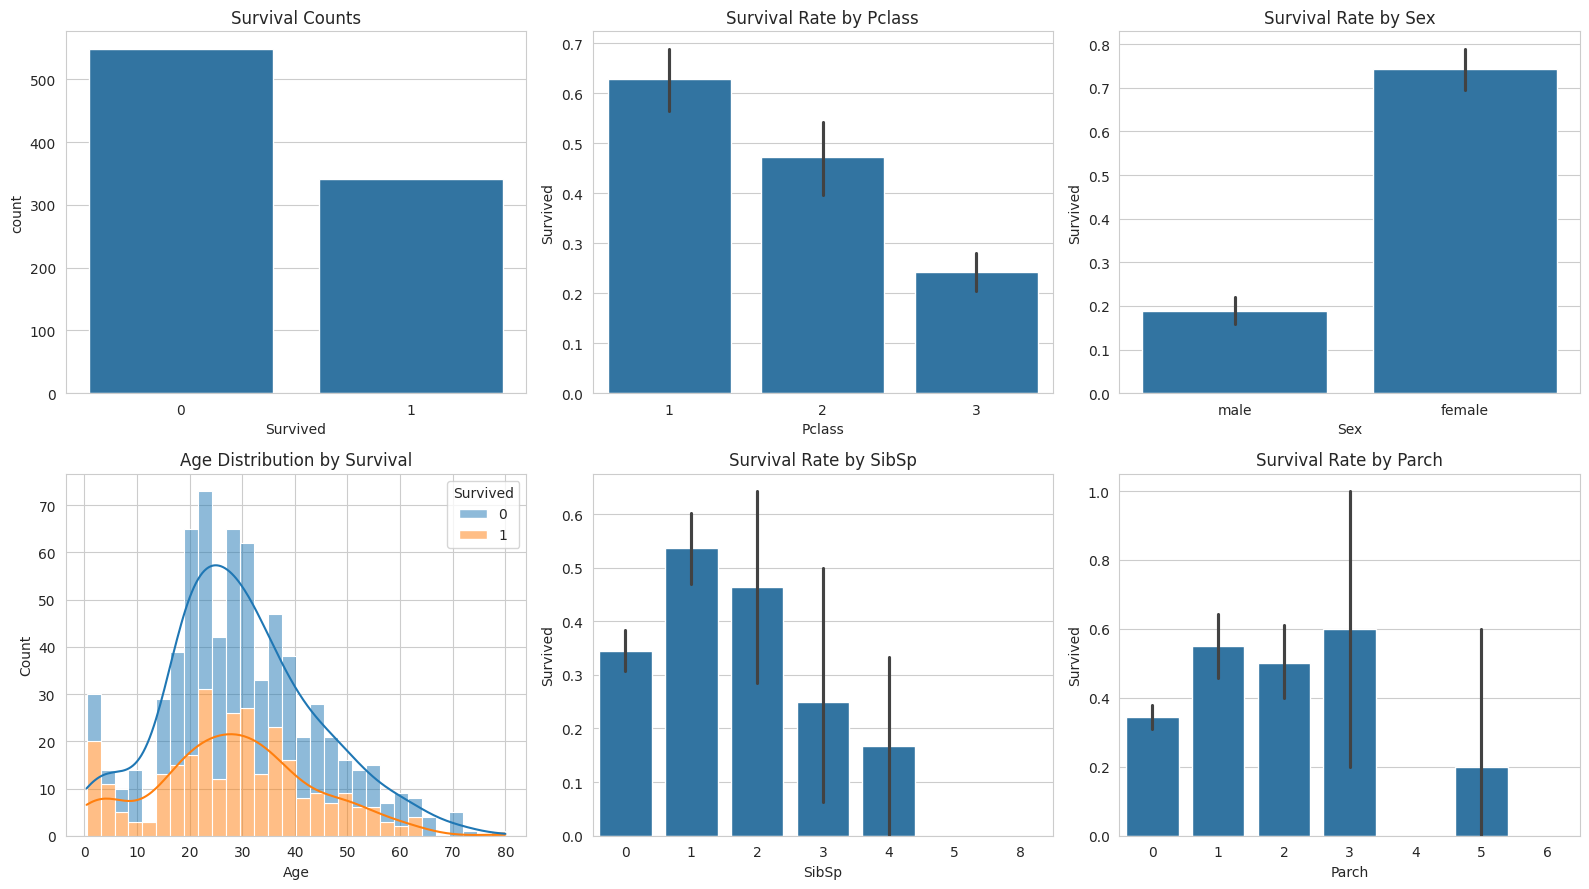

In [9]:
print('Overall survival rate: {:.2%}'.format(train_df['Survived'].mean()))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.countplot(data=train_df, x='Survived', ax=axes[0, 0])
axes[0, 0].set_title('Survival Counts')

sns.barplot(data=train_df, x='Pclass', y='Survived', ax=axes[0, 1])
axes[0, 1].set_title('Survival Rate by Pclass')

sns.barplot(data=train_df, x='Sex', y='Survived', ax=axes[0, 2])
axes[0, 2].set_title('Survival Rate by Sex')

sns.histplot(data=train_df, x='Age', hue='Survived', bins=30, kde=True, ax=axes[1, 0], multiple='stack')
axes[1, 0].set_title('Age Distribution by Survival')

sns.barplot(data=train_df, x='SibSp', y='Survived', ax=axes[1, 1])
axes[1, 1].set_title('Survival Rate by SibSp')

sns.barplot(data=train_df, x='Parch', y='Survived', ax=axes[1, 2])
axes[1, 2].set_title('Survival Rate by Parch')

plt.tight_layout()
plt.show()

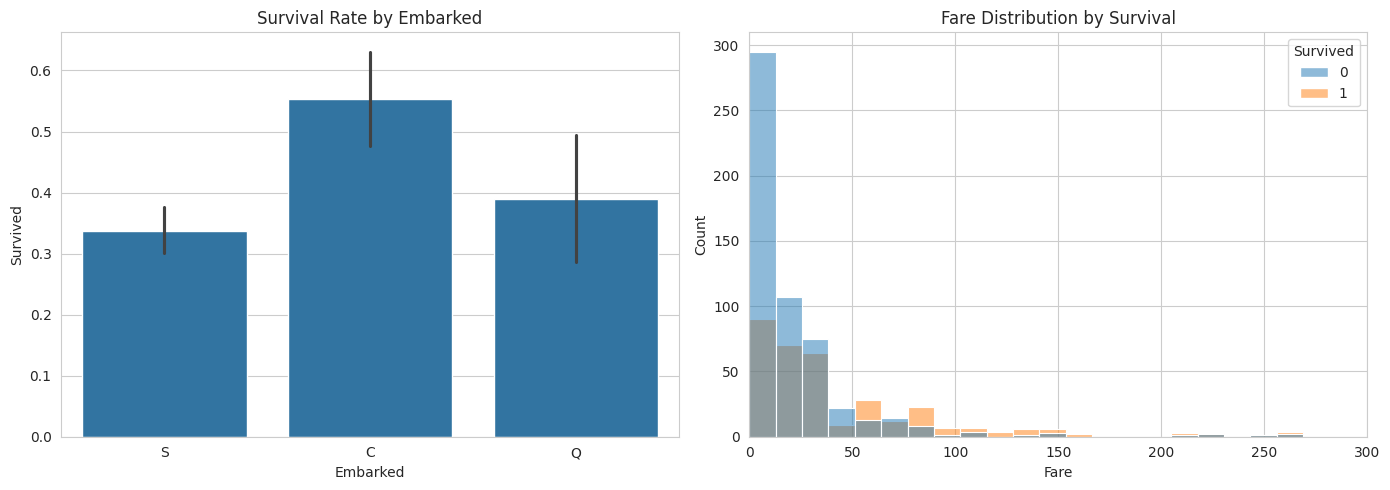

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=train_df, x='Embarked', y='Survived', ax=axes[0])
axes[0].set_title('Survival Rate by Embarked')

sns.histplot(data=train_df, x='Fare', hue='Survived', bins=40, ax=axes[1])
axes[1].set_title('Fare Distribution by Survival')
axes[1].set_xlim(0, 300)

plt.tight_layout()
plt.show()

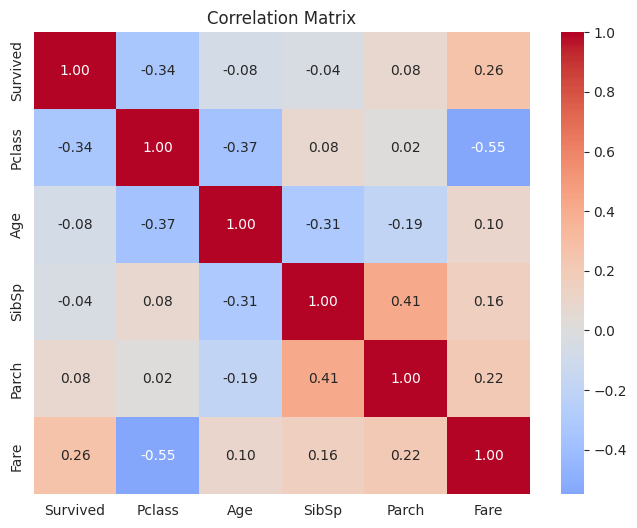

In [11]:
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 3. Feature Engineering

We combine train and test for consistent feature engineering, then split back out.

In [12]:
def engineer_features(df):
    df = df.copy()

    # Title extracted from Name
    df['Title'] = df['Name'].str.extract(r',\s*([^\.]*)\.')
    title_map = {
        'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
        'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
        'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
        'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare'
    }
    df['Title'] = df['Title'].replace(title_map)
    df.loc[~df['Title'].isin(['Mr', 'Mrs', 'Miss', 'Master', 'Rare']), 'Title'] = 'Rare'

    # Family size features
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # Deck from Cabin (first letter); 'M' = missing
    df['Deck'] = df['Cabin'].str[0]
    df['Deck'] = df['Deck'].fillna('M')

    # Ticket group size (how many passengers share the same ticket number)
    ticket_counts = df['Ticket'].value_counts()
    df['TicketGroupSize'] = df['Ticket'].map(ticket_counts)

    return df


train_len = len(train_df)
combined = pd.concat([train_df.drop(columns=['Survived']), test_df], axis=0, sort=False).reset_index(drop=True)
combined = engineer_features(combined)

# Impute Age by median within Title/Pclass groups (fit only on train rows to avoid leakage in spirit,
# but medians computed on combined for feature completeness is a common, acceptable practice here)
combined['Age'] = combined.groupby(['Title', 'Pclass'])['Age'].transform(lambda s: s.fillna(s.median()))
combined['Age'] = combined['Age'].fillna(combined['Age'].median())

# Fare: impute with median fare of the same Pclass
combined['Fare'] = combined.groupby('Pclass')['Fare'].transform(lambda s: s.fillna(s.median()))

# Embarked: impute with mode
combined['Embarked'] = combined['Embarked'].fillna(combined['Embarked'].mode()[0])

# Age bins and Fare bins (help tree models find nonlinear splits, useful signal for linear models too)
combined['AgeBin'] = pd.cut(combined['Age'], bins=[0, 12, 18, 35, 60, 100],
                             labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])
combined['FareBin'] = pd.qcut(combined['Fare'], q=4, labels=['Low', 'Mid', 'High', 'VeryHigh'])

print(combined.isnull().sum()[combined.isnull().sum() > 0])
combined.head()

Cabin    1014
dtype: int64


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,Deck,TicketGroupSize,AgeBin,FareBin
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0,M,1,YoungAdult,Low
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0,C,2,Adult,VeryHigh
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1,M,1,YoungAdult,Mid
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0,C,2,YoungAdult,VeryHigh
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1,M,1,YoungAdult,Mid


In [13]:
feature_cols = [
    'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
    'Title', 'FamilySize', 'IsAlone', 'Deck', 'TicketGroupSize', 'AgeBin', 'FareBin'
]

numeric_features = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'TicketGroupSize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'IsAlone', 'Deck', 'AgeBin', 'FareBin']

X_full = combined[feature_cols]
X_train_raw = X_full.iloc[:train_len].reset_index(drop=True)
X_test_raw = X_full.iloc[train_len:].reset_index(drop=True)
y_train = train_df['Survived'].reset_index(drop=True)

print(f'X_train_raw shape: {X_train_raw.shape}')
print(f'X_test_raw shape:  {X_test_raw.shape}')

X_train_raw shape: (891, 14)
X_test_raw shape:  (418, 14)


## 4. Preprocessing Pipeline

In [15]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

## 5. Model Comparison (Cross-Validation)

In [16]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'SVC': SVC(probability=True, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=7),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    scores = cross_val_score(pipe, X_train_raw, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f'{name:20s}  mean={scores.mean():.4f}  std={scores.std():.4f}')

LogisticRegression    mean=0.8339  std=0.0133
RandomForest          mean=0.8238  std=0.0101
GradientBoosting      mean=0.8395  std=0.0231
SVC                   mean=0.8328  std=0.0154
KNN                   mean=0.8305  std=0.0138


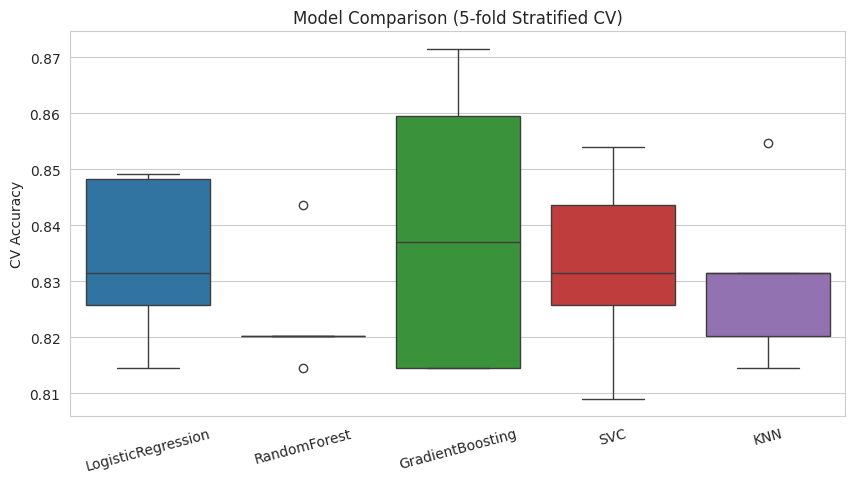

,0
GradientBoosting,0.839470
LogisticRegression,0.833877
SVC,0.832760
KNN,0.830500
RandomForest,0.823771


In [17]:
results_df = pd.DataFrame(results)
plt.figure(figsize=(10, 5))
sns.boxplot(data=results_df)
plt.ylabel('CV Accuracy')
plt.title('Model Comparison (5-fold Stratified CV)')
plt.xticks(rotation=15)
plt.show()

results_df.mean().sort_values(ascending=False)

## 6. Hyperparameter Tuning

We tune the strongest model from the comparison above (edit `best_model_name` / the param grid if a different model wins on your run).

In [18]:
best_model_name = results_df.mean().idxmax()
print(f'Best model from CV: {best_model_name}')

Best model from CV: GradientBoosting


In [19]:
param_grids = {
    'RandomForest': {
        'classifier__n_estimators': [200, 300, 500],
        'classifier__max_depth': [4, 6, 8, None],
        'classifier__min_samples_split': [2, 4, 6],
        'classifier__min_samples_leaf': [1, 2, 4],
    },
    'GradientBoosting': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__max_depth': [2, 3, 4],
    },
    'SVC': {
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__gamma': ['scale', 'auto', 0.01, 0.1],
        'classifier__kernel': ['rbf'],
    },
    'LogisticRegression': {
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l2'],
    },
    'KNN': {
        'classifier__n_neighbors': [3, 5, 7, 9, 11, 15],
        'classifier__weights': ['uniform', 'distance'],
    },
}

best_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', models[best_model_name])])

grid_search = GridSearchCV(
    best_pipe,
    param_grid=param_grids[best_model_name],
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_raw, y_train)

print(f'Best CV accuracy: {grid_search.best_score_:.4f}')
print(f'Best params: {grid_search.best_params_}')

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best CV accuracy: 0.8439
Best params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__n_estimators': 100}


## 7. Validation Check

A quick holdout check (in addition to CV) just to see a confusion matrix / classification report.

Holdout accuracy: 0.8045

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       110
           1       0.80      0.65      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



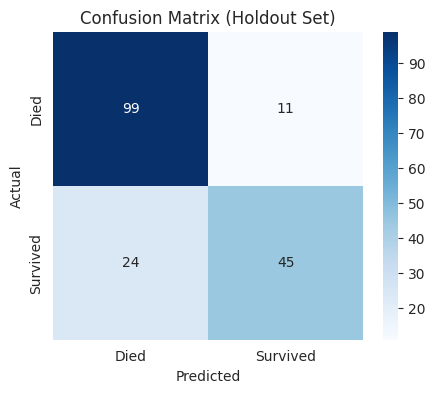

In [20]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_raw, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)

final_model = grid_search.best_estimator_
final_model.fit(X_tr, y_tr)
val_preds = final_model.predict(X_val)

print(f'Holdout accuracy: {accuracy_score(y_val, val_preds):.4f}\n')
print(classification_report(y_val, val_preds))

cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix (Holdout Set)')
plt.show()

## 8. Feature Importance (if supported by the chosen model)

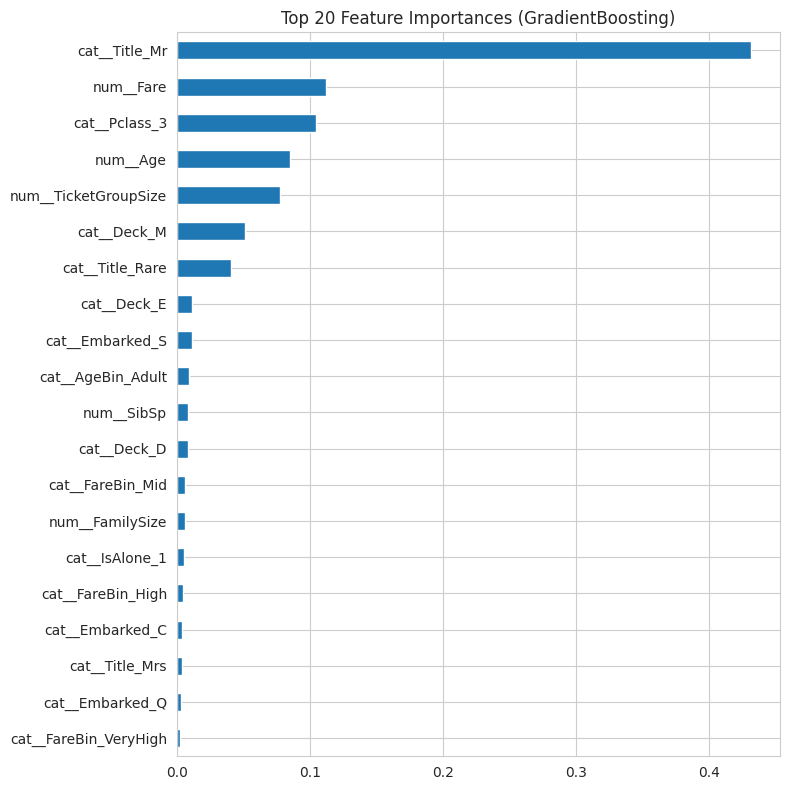

In [21]:
clf = final_model.named_steps['classifier']

if hasattr(clf, 'feature_importances_'):
    feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()
    importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)

    plt.figure(figsize=(8, 8))
    importances.head(20).sort_values().plot(kind='barh')
    plt.title(f'Top 20 Feature Importances ({best_model_name})')
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_model_name} does not expose feature_importances_.')

## 9. Final Fit on Full Training Data & Predict on Test Set

In [22]:
# Refit the tuned pipeline on ALL available training data before predicting on test
final_model = grid_search.best_estimator_
final_model.fit(X_train_raw, y_train)

test_predictions = final_model.predict(X_test_raw)
print(f'Predicted survival rate on test set: {test_predictions.mean():.2%}')

Predicted survival rate on test set: 36.12%


## 10. Create Submission File

In [23]:
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': test_predictions.astype(int)
})

assert submission.shape[0] == 418, 'Submission must have exactly 418 rows'
assert list(submission.columns) == ['PassengerId', 'Survived'], 'Columns must be PassengerId, Survived'

submission.to_csv('submission.csv', index=False)
print('Saved submission.csv')
submission.head()

Saved submission.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


## Next Steps / Ideas to Improve the Score

- Try stacking/ensembling multiple models (e.g. `VotingClassifier` or `StackingClassifier`).
- Engineer more features from `Cabin`, `Ticket` prefixes, or fare-per-person (`Fare / FamilySize`).
- Try `XGBoost`, `LightGBM`, or `CatBoost` for potentially stronger gradient boosting performance.
- Use `RandomizedSearchCV` or Bayesian optimization for a wider hyperparameter search.
- Inspect misclassified holdout passengers to spot patterns the model is missing.